# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student:** Kathryn Choi

**Date:** 9/4/2026

In [2]:
# Importing Google Drive to upload data files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Your Phase 1 solution to the problem goes here.

In [29]:
# Q1.1 - Cleaning the 'Price' variable
import pandas as pd
import numpy as np

# Reading csv file
df = pd.read_csv('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/airbnb_hw.csv')

# Looking at potential issues before cleaning
print(f"Sorted Values Before Cleaning: {sorted(df['Price'].unique())}")

# Checking for any missing values (no missing values found)
print(f"Number of Missing Values Before Cleaning: {df['Price'].isna().sum()}")

# Removing all dollar signs and commas
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# Converting 'Price' to a numeric data type
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Checking to make sure that the values are correctly ordered after cleaning
print(f"Sorted Values After Cleaning: {sorted(df['Price'].unique())}")

# Count number of missing values after cleaning
print(f"Number of Missing Values After Cleaning: {df['Price'].isna().sum()}")


# I removed the dollar signs and commas so that I could standardize all of the 'Price' values. For example, when the price goes over 999,
# some values may have a comma, like in 1,234. Furthermore, by removing the commas I could properly sort the 'Price' variable and see
# all of the 'Price' values listed from least to greater in the correct order. After removing all '$' and ',' I converted 'Price' to
# a numeric data type so that relevant functions like .mean() could be use and insights about the 'Price' variable could be gathered.
# There are no missing values in the 'Price' variable before or after cleaning.


Sorted Values Before Cleaning: ['1,000', '1,050', '1,065', '1,100', '1,111', '1,170', '1,174', '1,195', '1,200', '1,239', '1,250', '1,300', '1,350', '1,356', '1,368', '1,400', '1,495', '1,499', '1,500', '1,550', '1,600', '1,650', '1,700', '1,750', '1,800', '1,850', '1,900', '1,990', '1,999', '10', '10,000', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198'

In [30]:
# Q1.2 - Cleaning the 'subject_injury' variable
import pandas as pd
import numpy as np

# Reading csv file
df = pd.read_csv('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/mn_police_use_of_force.csv')


# Finding proportion of missing 'subject_injury' values
percent_missing = (df['subject_injury'].isna().sum()) / (len(df['subject_injury'])) * 100
print(f"Proportion Missing: {percent_missing:.2f}%")

# 76.19% of 'subject_injury' values are missing, which is a concern since a large majority of the data for that variable is not available.

# Replacing missing 'subject_injury' values with 'Unknown'
df['subject_injury'] = df['subject_injury'].fillna('Unknown')

# Cross-tabulating the cleaned 'subject_injury' variable with 'force_type' variable
display(pd.crosstab(df['subject_injury'], df['force_type']))


# Based on the cross-tabulation table, the primary force types for which the 'subject_injury' variable is missing are Baton, Bodily Force,
# Chemical Irritant, Improvised Weapon, Less Lethal, Maximal Restraint Technique, and Taser. I identified these force types based on if
# the total number of 'Unknown' cases was greater than or equal to the total number of 'No' or 'Yes' cases. The force types 'Less Lethal' and
# 'Maximal Restraint Technique' do not have any recorded 'Yes' or 'No' cases for the 'subject_injury' variable which shows that those force
# types never have subject injuries recorded. High-frequency force types such as 'Bodily Force,' 'Chemical Irritant,' and 'Taser' are also
# more likely to have unknown subject injuries recorded.

Proportion Missing: 76.19%


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Unknown,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [63]:
# Q2.1 & Q2.2 - Opening shark attack file and dropping empty columns
import pandas as pd
import numpy as np

# Opening shark attack file
df = pd.read_excel('/content/drive/MyDrive/Fall 2026/DS 3001 - Intro to Machine Learning/A01 - Data Wrangling/GSAF5.xls')

# Printing all of the column names BEFORE dropping the empty ones
print(f"Columns Before Cleaning: {df.columns.tolist()}")

# Coverting all "empty" columns (empty strings or strings with only whitespace) to NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Dropping all null columns
df = df.dropna(axis=1, how='all')

# Dropping unnamed columns
df = df.drop(columns=df.loc[:,df.columns.str.contains('^Unnamed')])

# Printing all of the column names AFTER dropping the empty ones
print(f"Columns After Cleaning: {df.columns.tolist()}")

Columns Before Cleaning: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']
Columns After Cleaning: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order']


Oldest Year Before Cleaning: 1940
Newest Year Before Cleaning: 2026
Oldest Year After Cleaning: 1940
Newest Year After Cleaning: 2026


Text(0, 0.5, 'Number of Attacks')

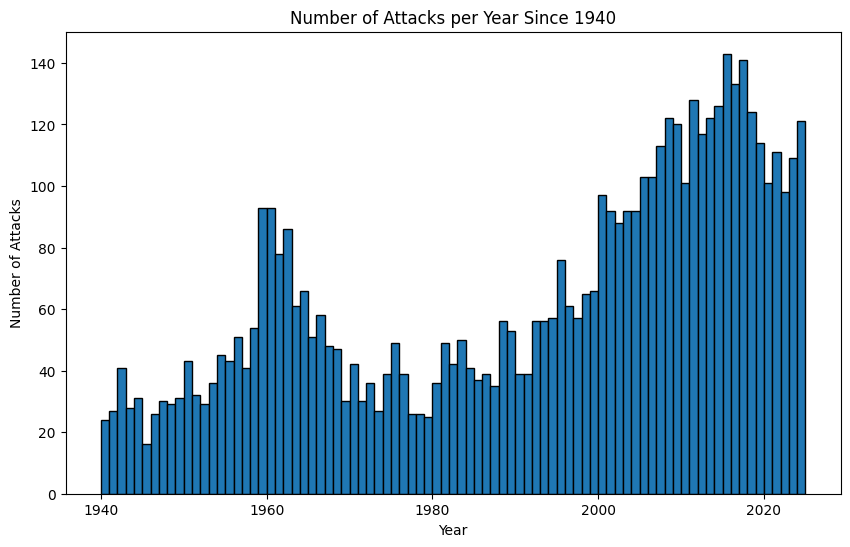

In [55]:
# Q2.3 - Cleaning the 'year' variable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Converting 'Year' to a integer data type
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'] = df['Year'].astype(int)  # See note below

# Note: for some reason, the line above throws an error the first time it runs, but if you delete the line, rerun the code block (which will
# still throw an error), and then undo delete the line above, the code block will work.


# Printing the range of 'Year' values
print(f"Oldest Year Before Cleaning: {df['Year'].min():.0f}")
print(f"Newest Year Before Cleaning: {df['Year'].max():.0f}")

# Before cleaning, the years range from 0 to 2026


# Filtering to focus on attacks since 1940
df = df[df['Year'] >= 1940]

# Printing the range of 'Year' values
print(f"Oldest Year After Cleaning: {df['Year'].min():.0f}")
print(f"Newest Year After Cleaning: {df['Year'].max():.0f}")

# Graphing the pattern of attacks since 1940
plt.figure(figsize=(10,6))
plt.title("Number of Attacks per Year Since 1940")
plt.hist(df['Year'], bins=range(df['Year'].min(), df['Year'].max()), edgecolor='black')
plt.xlabel("Year")
plt.ylabel("Number of Attacks")


# Based on the graph, the number of attacks is increasing over time.

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s' '23 & 20' 5
 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30' '16 to 18' '

<Axes: >

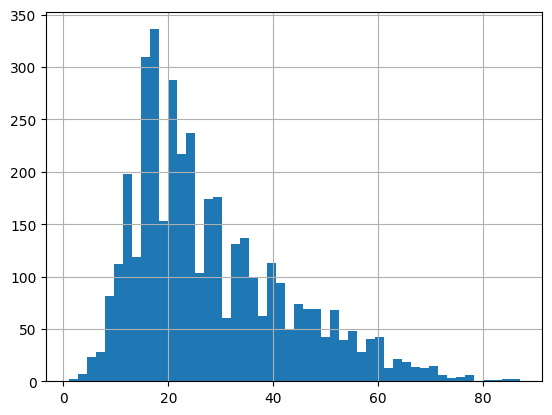

In [64]:
# Q2.4 - Cleaning the 'age' variable
import pandas as pd
import numpy as np

# Printing all of the different age values before cleaning
print(df['Age'].unique())

# Converting 'Age' to a integer data type, setting all errors (not strictly numeric values) to NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Creating a histogram of victim ages
df['Age'].hist(bins=50)

In [56]:
# Q2.5 - Proportion of male victims
import pandas as pd
import numpy as np

# Printing all of the different sex values before cleaning
print(f"Unique Sex Values Before Cleaning: {df['Sex'].unique()}")

# Getting rid of whitespaces first and standardizing casing
df['Sex_Cleaned'] = df['Sex'].astype(str).str.lower().str.strip()

# A function to sort data values as sex categories
def sort_sex(sex_value):
  if 'm' in sex_value:
    return 'M'
  elif 'f' in sex_value:
    return 'F'
  else:
    return 'Unknown'

df['Sex_Cleaned'] = df['Sex_Cleaned'].apply(sort_sex)

# Printing all of the different sex values after cleaning
print(f"Unique Sex Values After Cleaning: {df['Sex_Cleaned'].unique()}")

# Finding the proportion of men
prop_male = (df[df['Sex_Cleaned'] == 'M'].shape[0]) / (df.shape[0]) * 100
print(f"Proportion of Male Victims: {prop_male:.2f}%")

Unique Sex Values Before Cleaning: ['F' 'M' 'M ' 'M F' '?' 'F ' nan ' M' 'm' 'lli' 'M x 2']
Unique Sex Values After Cleaning: ['F' 'M' 'Unknown']
Proportion of Male Victims: 78.75%


In [65]:
# Q2.6 - Cleaning the 'Type' variable
import pandas as pd
import numpy as np

# Printing all of the different type values before cleaning
print(f"Unique Type Values Before Cleaning: {df['Type'].unique()}")

# Removing all whitespaces and standardizing casing
df['Type_Cleaned'] = df['Type'].astype(str).str.lower().str.strip()

# A function to sort data values into type categories
def sort_type(type_value):
  if 'unprovoked' in type_value:
    return 'Unprovoked'
  elif 'provoked' in type_value:
    return 'Provoked'
  else:
    return 'Unknown'

df['Type_Cleaned'] = df['Type_Cleaned'].apply(sort_type)

# Printing all of the different type values after cleaning
print(f"Unique Type Values After Cleaning: {df['Type_Cleaned'].unique()}")

# Finding the proportion of unprovoked attacks
prop_unp = (df[df['Type_Cleaned'] == 'Unprovoked'].shape[0]) / (df.shape[0]) * 100
print(f"Proportion of Unprovoked Attacks: {prop_unp:.2f}%")

Unique Type Values Before Cleaning: ['Unprovoked' 'Provoked' 'Questionable' 'UNprovoked' 'unprovoked'
 ' Provoked' 'Watercraft' 'Sea Disaster' nan '?' 'Unconfirmed'
 'Unverified' 'Invalid' 'Under investigation' 'Boat']
Unique Type Values After Cleaning: ['Unprovoked' 'Provoked' 'Unknown']
Proportion of Unprovoked Attacks: 73.95%


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]